<a href="https://colab.research.google.com/github/ParamAhuja/DL_Notebooks/blob/main/transfer_learning_VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Architecture:
  
 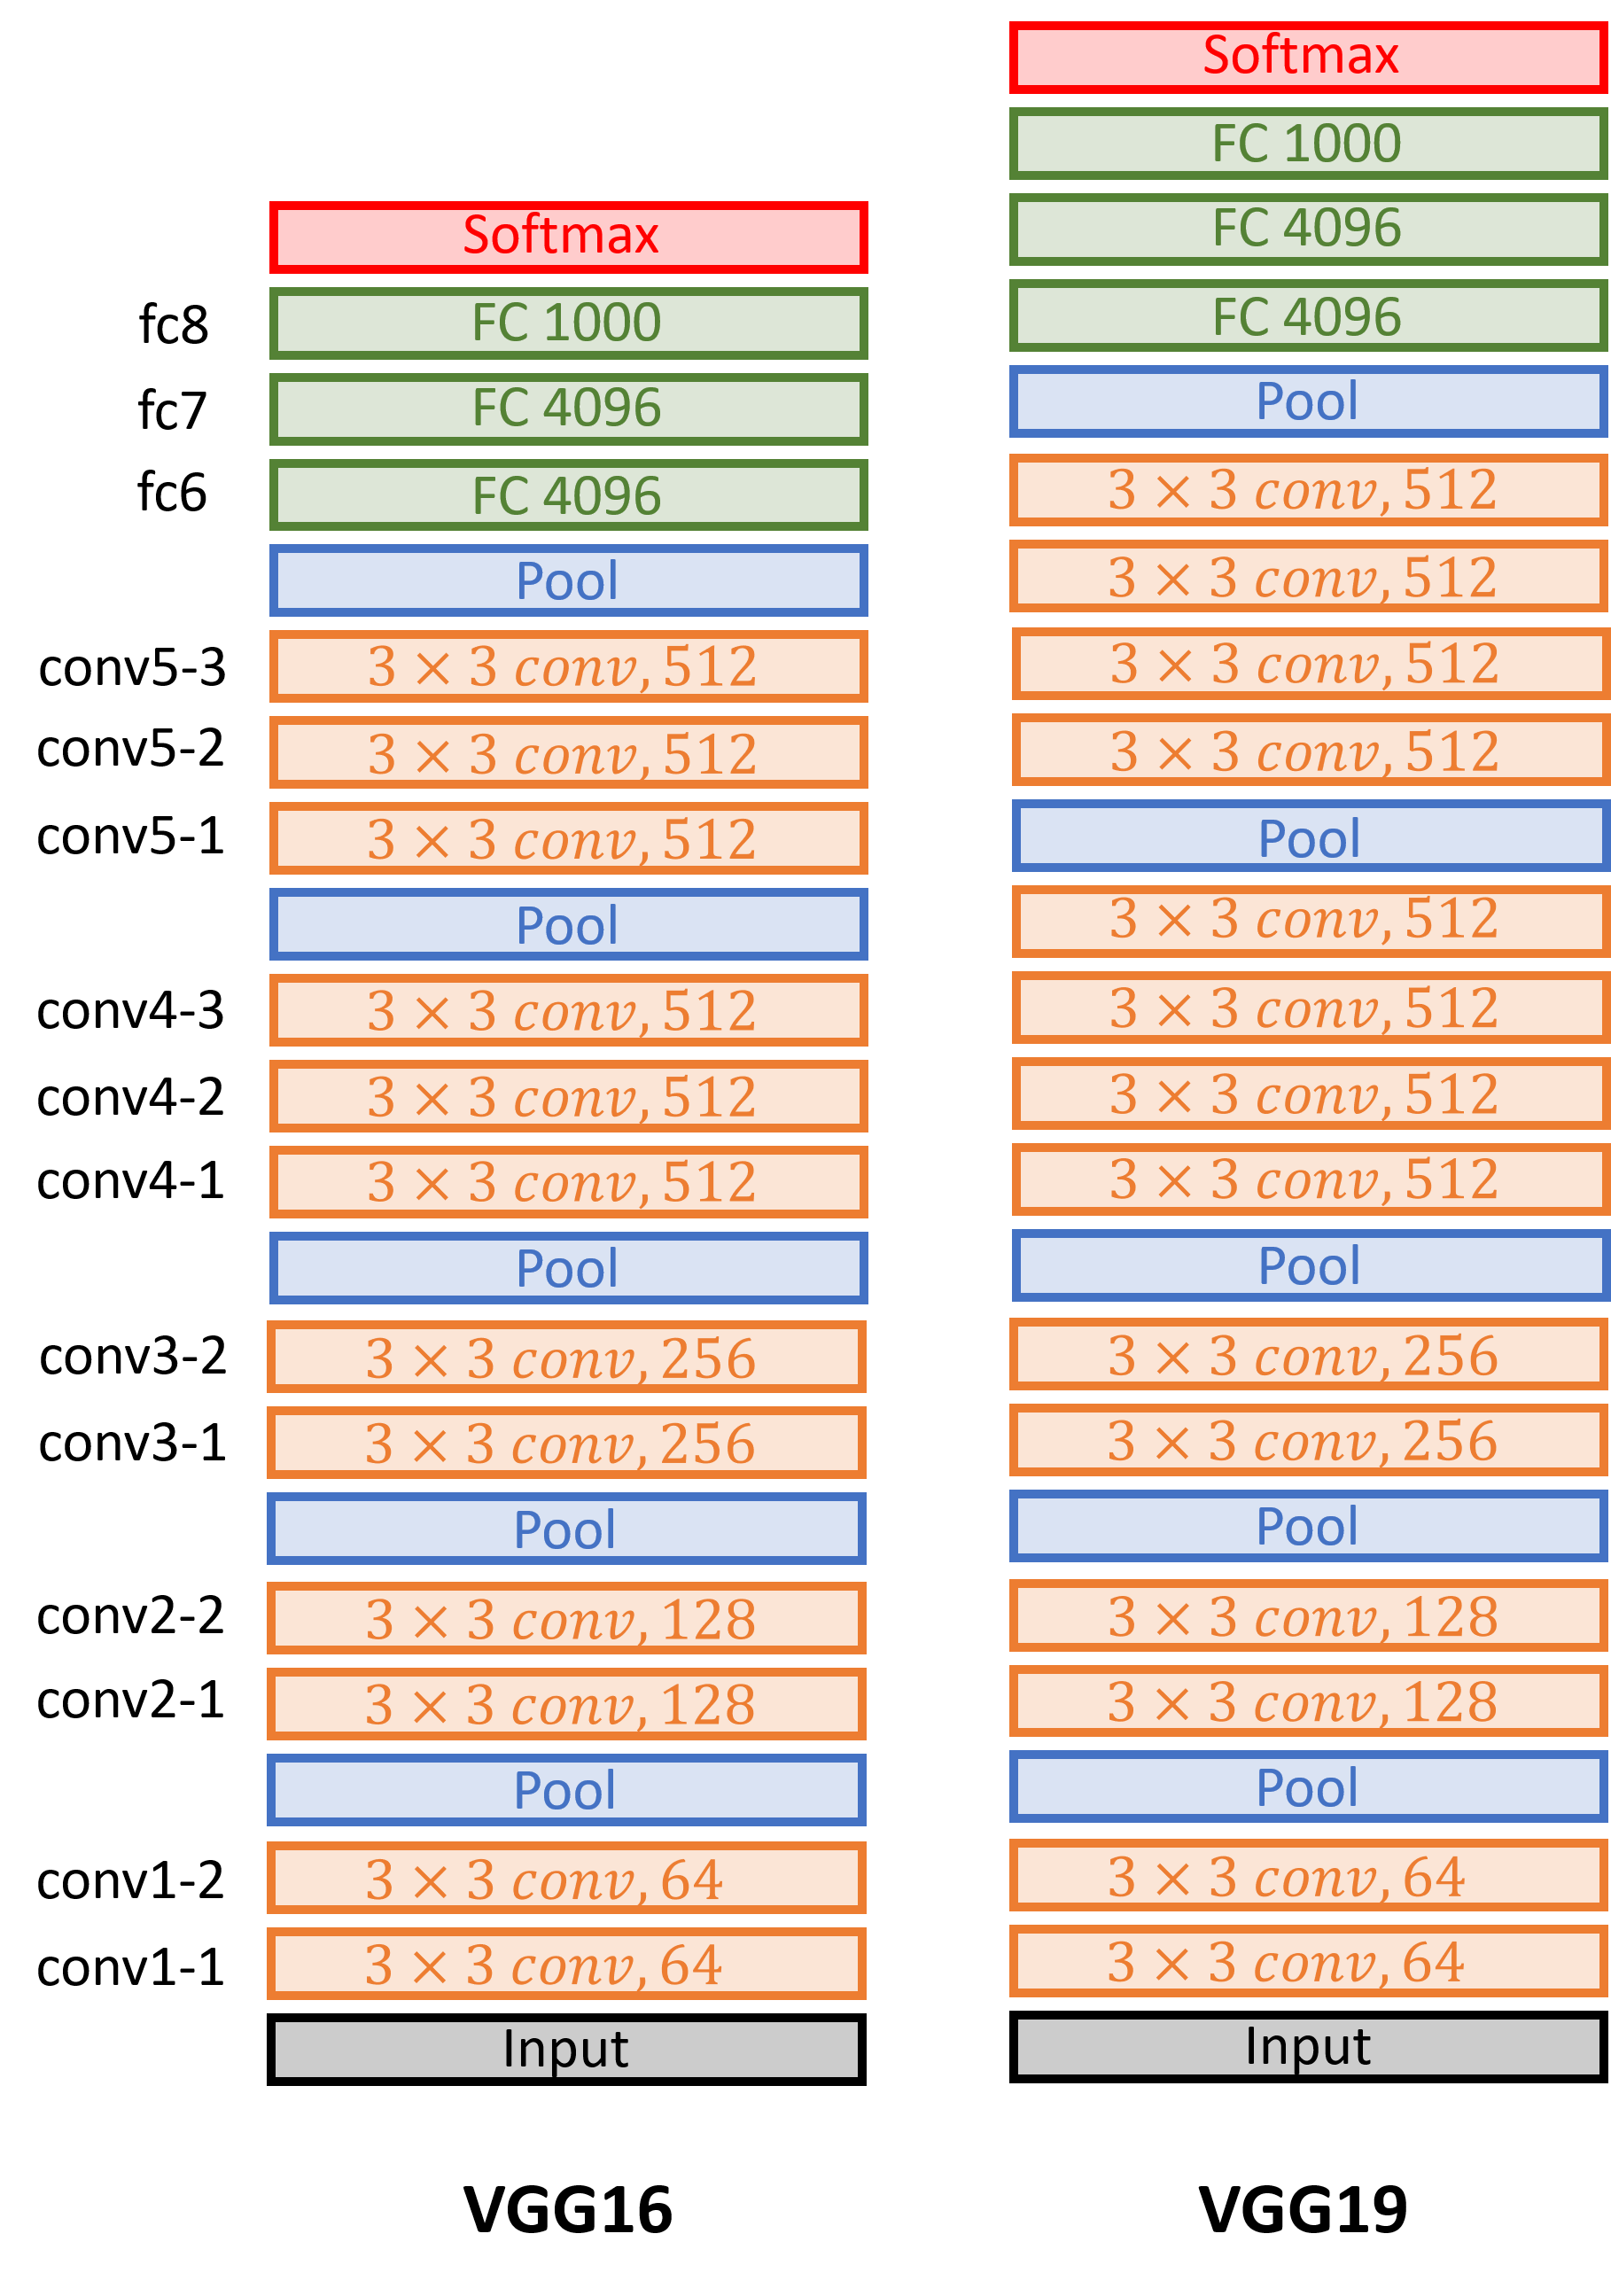

1. extract features for transfer learning
2. add top of model
3. freeze base completly (feature extraction) or leave later layers trainable (fine-tuning)
4. get data, augment data
5. train
6. eval and infer

# get vgg19 features from a chosen block-layer

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import plot_model
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization

In [ ]:
# get model, you can use outputs=base_model.get_layer('block4_pool').output to get arbitrary layer choice
base_model = VGG16(weights='imagenet', include_top=False, input_shape = (150,150,3))


In [ ]:
model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# freeze the base
base_model.trainable = False

In [51]:
# FINE TUNING FROM CONV 5-1
# base_model.trainable = True

# set_trainable = False

# for layer in base_model.layers:
#   if layer.name == 'block5_conv1':
#     set_trainable = True
#   if set_trainable:
#     layer.trainable = True
#   else:
#     layer.trainable = False

# for layer in base_model.layers:
#   print(layer.name,layer.trainable)

# GENERALLY, FOR FINE TUNING, LR IS KEPT LOWER, like 1e-5, keras.optimizers.RMSProp(lr = 1e-5)
# ACCURACY GOES UPTO 95%, even without augentation

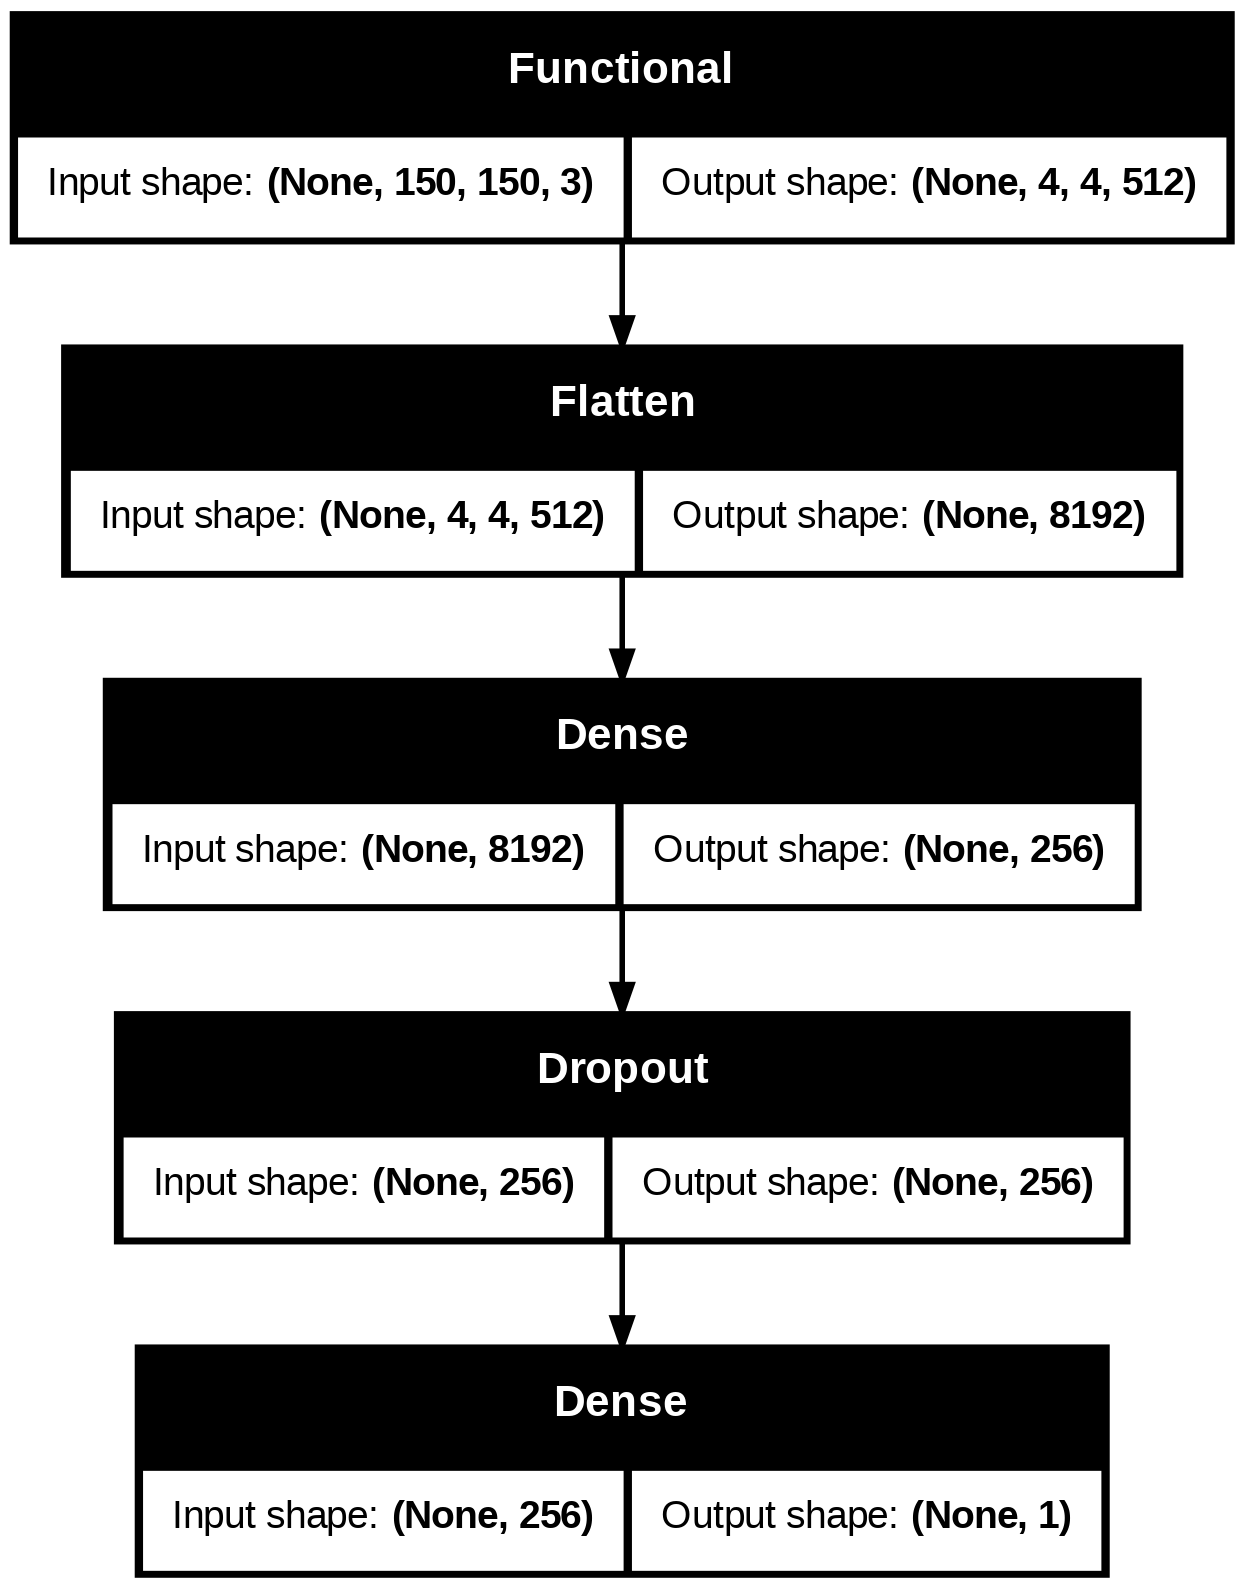

In [ ]:
plot_model(model, show_shapes=True)

# get data

In [ ]:
from datasets import load_dataset

dataset_from_hub = load_dataset("ParamDev/ImageClassification")

train_data_from_hub = dataset_from_hub["train"]
test_data_from_hub = dataset_from_hub["test"]

dataset_from_hub

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 5000
    })
})

In [ ]:
import os
from PIL import Image

# Create directories for saving images if they don't exist
if not os.path.exists("train/dogs"):
    os.makedirs("train/dogs")
if not os.path.exists("train/cats"):
    os.makedirs("train/cats")
if not os.path.exists("test/dogs"):
    os.makedirs("test/dogs")
if not os.path.exists("test/cats"):
    os.makedirs("test/cats")

# Function to save images
def save_images(dataset, split_name):
    for i, example in enumerate(dataset):
        image = example["image"]
        label = example["label"] # 0 for cat, 1 for dog

        # Determine the directory based on the label
        if label == 0:
            label_dir = "cats"
        else:
            label_dir = "dogs"

        # Save the image
        image_path = os.path.join(split_name, label_dir, f"image_{i}.jpg")
        image.save(image_path)

# Save train and test images
save_images(train_data_from_hub, "train")
save_images(test_data_from_hub, "test")

print("Images saved to train/dogs, train/cats, test/dogs, and test/cats directories.")


Images saved to train/dogs, train/cats, test/dogs, and test/cats directories.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32

train_data_gen = ImageDataGenerator(
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    # normalize:
    rescale = 1. / 255.
)
test_data_gen = ImageDataGenerator(rescale = 1. / 255.)


train_gen = train_data_gen.flow_from_directory( # use flow_from_directory for a folder of images
    "/content/train",      # dir
    target_size=(150,150), # size of images output
    batch_size = batch_size,
    class_mode = "binary") # for binary labels

test_gen = test_data_gen.flow_from_directory( # use flow_from_directory for a folder of images
    "/content/test",       # dir
    target_size=(150,150), # size of images output
    batch_size = batch_size,
    class_mode = "binary") # for binary labels

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


# train and eval

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_gen,
                    epochs=5,
                    steps_per_epoch= 20000 // batch_size,
                    validation_data=test_gen,
                    validation_steps = 5000 // batch_size,
                    )

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 254ms/step - accuracy: 0.8145 - loss: 0.4896 - val_accuracy: 0.9073 - val_loss: 0.2113
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 256ms/step - accuracy: 0.8970 - loss: 0.2480 - val_accuracy: 0.9054 - val_loss: 0.2132
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 152s 244ms/step - accuracy: 0.9045 - loss: 0.2266 - val_accuracy: 0.9137 - val_loss: 0.1988
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 246ms/step - accuracy: 0.9055 - loss: 0.2166 - val_accuracy: 0.9060 - val_loss: 0.2280
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 245ms/step - accuracy: 0.9124 - loss: 0.2096 - val_accuracy: 0.9179 - val_loss: 0.1912


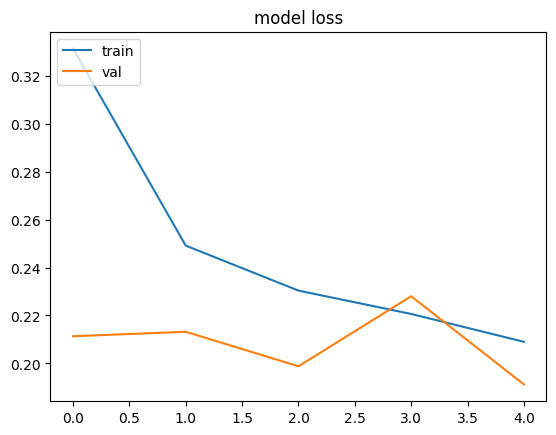

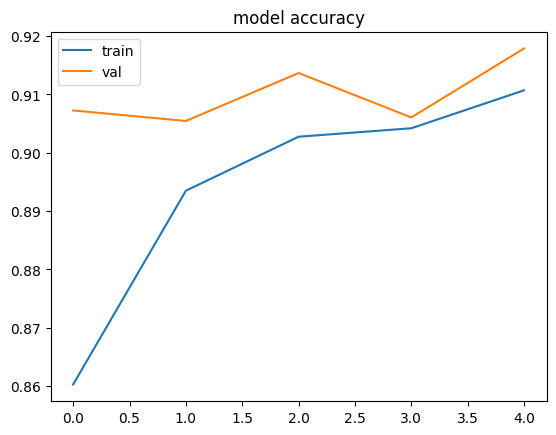

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# predict

In [ ]:
import requests
url = 'https://github.com/ParamAhuja/DL_Notebooks/raw/main/datasets/kitty-cat-kitten-pet-45201.jpeg'
img_filename = 'kitty.jpeg'

response = requests.get(url)
if response.status_code == 200:
    with open(img_filename, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded image to {img_filename}")
else:
    print(f"Failed to download image. Status code: {response.status_code}")

Downloaded image to kitty.jpeg


In [ ]:
import requests
url = 'https://github.com/ParamAhuja/DL_Notebooks/raw/main/datasets/doggo.jpg'
img_filename = 'doggo.jpeg'

response = requests.get(url)
if response.status_code == 200:
    with open(img_filename, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded image to {img_filename}")
else:
    print(f"Failed to download image. Status code: {response.status_code}")

Downloaded image to doggo.jpeg


In [ ]:
img_path = '/content/kitty.jpeg'
img = keras.utils.load_img(img_path, target_size=(150, 150))
x = keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

prediction = model.predict(x)
prediction
# 0 is cat

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step


array([[0.]], dtype=float32)

In [ ]:
img_path = '/content/doggo.jpeg'
img = keras.utils.load_img(img_path, target_size=(150, 150))
x = keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

prediction = model.predict(x)
prediction
# 1 is dog

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


array([[1.]], dtype=float32)